In [109]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from pathlib import Path
import json

from higashi.Higashi_backend.Modules import log_zinb_positive
from scoit.cell_analysis import umap_visualize
from sklearn.preprocessing import MinMaxScaler

In [141]:
from examples.case_studies.PEA_STA_analysis import load_data

expression_data, methylation_data, labels = load_data()

In [142]:
len(labels)

210

In [143]:
def remove_all_nan_columns(data, remove_all_zeros=True):
    print('Input #cols', data.shape[1])
    valid_cols = np.all(~np.isnan(data), axis=0)
    data = data[:, valid_cols]
    print('After remove all nan', data.shape[1])

    if remove_all_zeros:
        # 删除全是0的列。
        valid_cols = ~np.all(np.abs(data) < 1e-5, axis=0)
        data = data[:, valid_cols]
        print('After remove all zeros', data.shape[1])

    return data

In [144]:
expression_data_clean = remove_all_nan_columns(expression_data)
methylation_data_clean = remove_all_nan_columns(methylation_data)

Input #cols 141
After remove all nan 88
After remove all zeros 76
Input #cols 141
After remove all nan 78
After remove all zeros 77


Text(0.5, 1.0, 'methylation_data_clean')

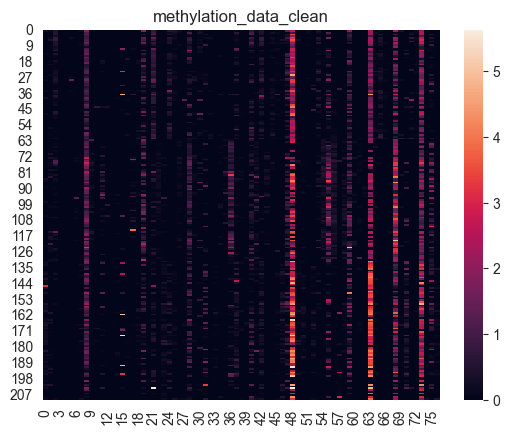

In [145]:
sns.heatmap(methylation_data_clean)
plt.title('methylation_data_clean')

Text(0.5, 1.0, 'expression_data_clean')

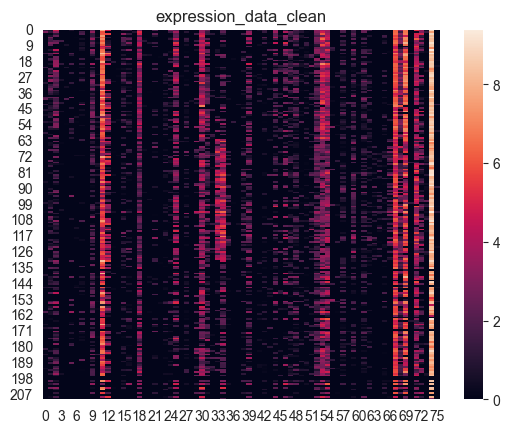

In [146]:
sns.heatmap(expression_data_clean)
plt.title('expression_data_clean')

In [147]:
def get_edges_weights_from_omics(data, omics_id, gene_offset):
    edges = np.nonzero(np.abs(data) > 1e-5)
    weights = data[edges]
    edges = edges + (np.ones_like(edges[0]) * omics_id, )
    edges = np.array(edges).T
    assert np.all(edges.max(0)[:-1] == np.array(data.shape) - 1)
    edges[:, 1] += gene_offset
    return edges, weights

In [148]:
expression_edges, expression_weights = get_edges_weights_from_omics(expression_data_clean, 0, 0)
methylation_edges, methylation_weights = get_edges_weights_from_omics(methylation_data_clean, 1, expression_data_clean.shape[1])

In [149]:
expression_edges.shape, expression_weights.shape, methylation_edges.shape, methylation_weights.shape

((5536, 3), (5536,), (4440, 3), (4440,))

In [150]:
expression_edges.max(0), methylation_edges.max(0)

(array([209,  75,   0]), array([209, 152,   1]))

In [151]:
def concat_edges_weights(edges_list, weights_list):
    return np.concatenate(edges_list, axis=0), np.concatenate(weights_list, axis=0)

In [152]:
edges, weights = concat_edges_weights([expression_edges, methylation_edges], [expression_weights, methylation_weights])

In [153]:
edges.shape, weights.shape

((9976, 3), (9976,))

In [154]:
weights.min(), weights.max()

(0.001, 9.391)

In [155]:
np.any(np.abs(weights) < 1e-5)

False

In [156]:
save_edges_and_weights('./data/PEA_STA', edges=edges, weights=weights, train_size=0.8, normalization=False)

In [157]:
train_data = np.load('./data/PEA_STA/train_data.npz', allow_pickle=True)
test_data = np.load('./data/PEA_STA/test_data.npz', allow_pickle=True)

In [158]:
train_data['train_weight'].shape

(9976,)

In [159]:
np.any(np.any(train_data['train_weight'] < 1e-5))

False

In [160]:
train_data['nums_type']

array([210, 153,   2])

In [161]:
!mkdir -p ./embeddings/hgnn/PEA_STA

In [162]:
!python3 hgnn/main_torch_zinb.py --data PEA_STA --feature adj --loss zinb --iter 50 && mv ./*.npy ./embeddings/hgnn/PEA_STA

1.0 -0.5
model_no_randomwalk
Use train_weight (9976,)
Node type num [210 153   2]
embeddings_initial [False, False, False]
[1.179 0.741 4.785 ... 1.606 0.339 0.517] 0.001 9.391
walk type 
adding pad idx
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
dict_size 9976 9976
train data amount 9976
64
tensor([  0, 210, 363, 365])
w.shape (210, 155)
(210, 155)
w.shape (153, 212)
(153, 212)
w.shape (2, 363)
(2, 363)
self.input_size [155, 212, 363]
inp 155 out 64 weight.shape torch.Size([64, 155])
fan_in 155 12.449899597988733
inp 212 out 64 weight.shape torch.Size([64, 212])
fan_in 212 14.560219778561036
inp 363 out 64 weight.shape torch.Size([64, 363])
fan_in 363 19.05255888325765
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
error MultipleEmbedding-1
 MultipleEmbedding-1           [[-1, 64], [-1]]               0
  

## Analysis

In [163]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scoit.cell_analysis import umap_visualize
from hgnn.hypergraph import *
from torch.utils.data import TensorDataset, DataLoader
from torch import nn
from torch.optim import Adam
import torch.nn.functional as F
import torch
from hgnn.phasing import *

In [164]:
cell_embeddings = np.load('./embeddings/hgnn/PEA_STA/mymodel_0.npy', allow_pickle=True)
gene_embeddings = np.load('./embeddings/hgnn/PEA_STA/mymodel_1.npy', allow_pickle=True)
omic_embeddings = np.load('./embeddings/hgnn/PEA_STA/mymodel_2.npy', allow_pickle=True)


In [165]:
cell_embeddings.shape

(210, 64)

{'NMI': 0.693683170765756,
 'ARI': 0.5418872339918281,
 'FMI': 0.7314055654107023}

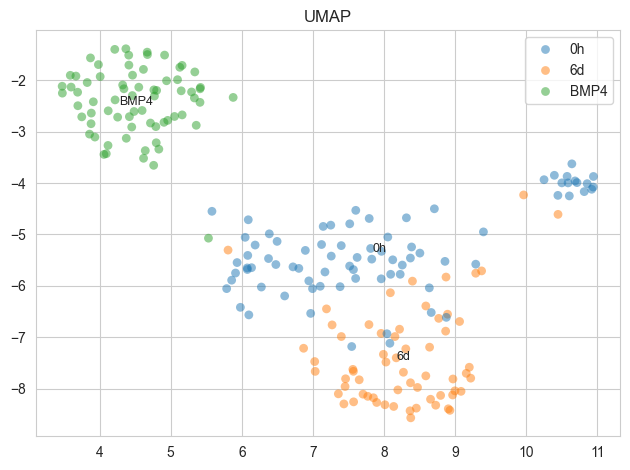

In [166]:
umap_visualize(cell_embeddings, labels)

## Phasing

In [167]:
G = torch.tensor(gene_embeddings, dtype=torch.float)
C = torch.tensor(cell_embeddings, dtype=torch.float)
O = torch.tensor(omic_embeddings, dtype=torch.float)
X_np = np.concatenate([expression_data_clean, methylation_data_clean], axis=1)
X_np = MinMaxScaler().fit_transform(X_np)
X = torch.tensor(X_np, dtype=torch.float)

In [168]:
epochs = 2000
embed_dim = C.shape[1]
# 超参，按需要调
alpha = 0.001
k = 3
lr = 1e-3
omics_offset = expression_data_clean.shape[1]
num_cells = C.shape[0]
num_genes = G.shape[0]
embed_dim, omics_offset

(64, 76)

In [169]:
model, histories = train_phasing_model(
    embed_dim=embed_dim,
    omics_offset=omics_offset,
    epochs=epochs,
    lr=lr,
    k=k,
    alpha=alpha,
    activations=[F.relu, F.relu],
    recon_loss=[log_zinb_positive, log_zinb_positive],
    C=C, G=G, O=O, X=X,
)

TypeError: log_zinb_positive() missing 2 required positional arguments: 'theta' and 'pi'

Text(0.5, 1.0, 'Phasing Loss vs Epoch')

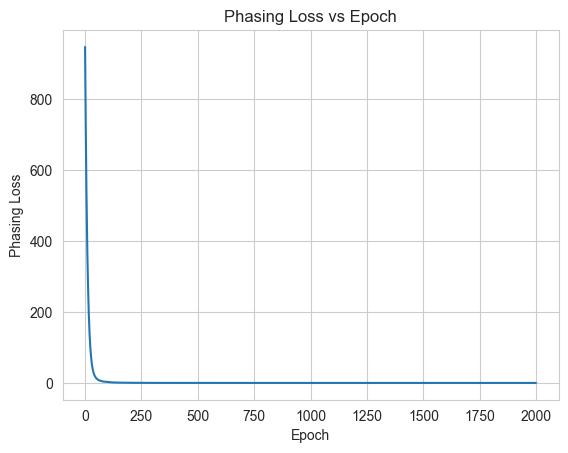

In [104]:
plt.plot(histories['history'])
plt.xlabel('Epoch')
plt.ylabel('Phasing Loss')
plt.title('Phasing Loss vs Epoch')

Text(0.5, 1.0, 'Reconstruction Loss vs Epoch')

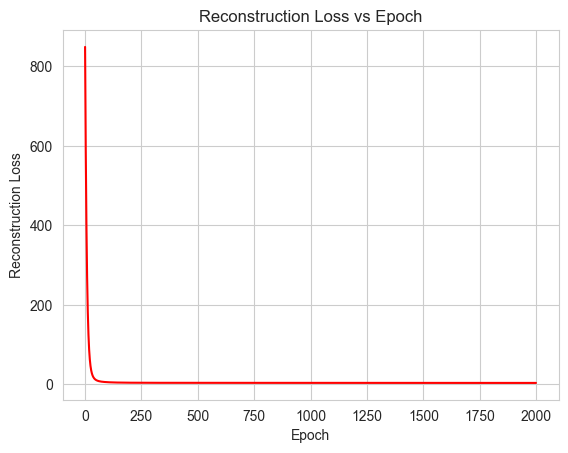

In [74]:
plt.plot(histories['history_recon'], color='red')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.title('Reconstruction Loss vs Epoch')

Text(0.5, 1.0, 'Regularization Loss vs Epoch')

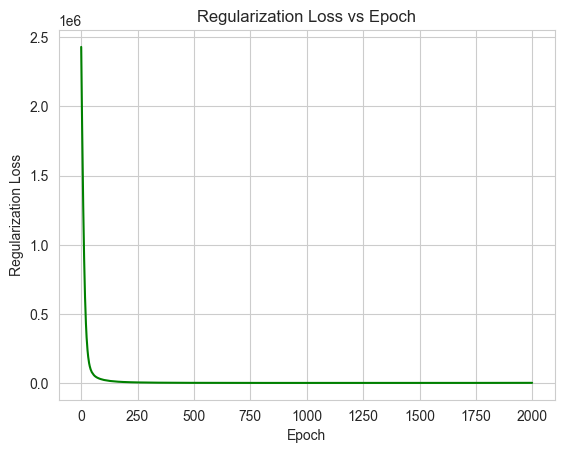

In [75]:
plt.plot(histories['history_reg'], color='green')
plt.xlabel('Epoch')
plt.ylabel('Regularization Loss')
plt.title('Regularization Loss vs Epoch')

In [105]:
Xp0, Xp1, Xm0, Xm1 = model.predict(G, C, O)

In [106]:
np.all(Xp0 < 1), np.all(Xp1 < 1), np.all(Xm0 < 1), np.all(Xm1 < 1)

(True, True, True, True)

In [107]:
X.min(), X.max()

(tensor(0.), tensor(1.))

Text(0.5, 1.0, 'X1')

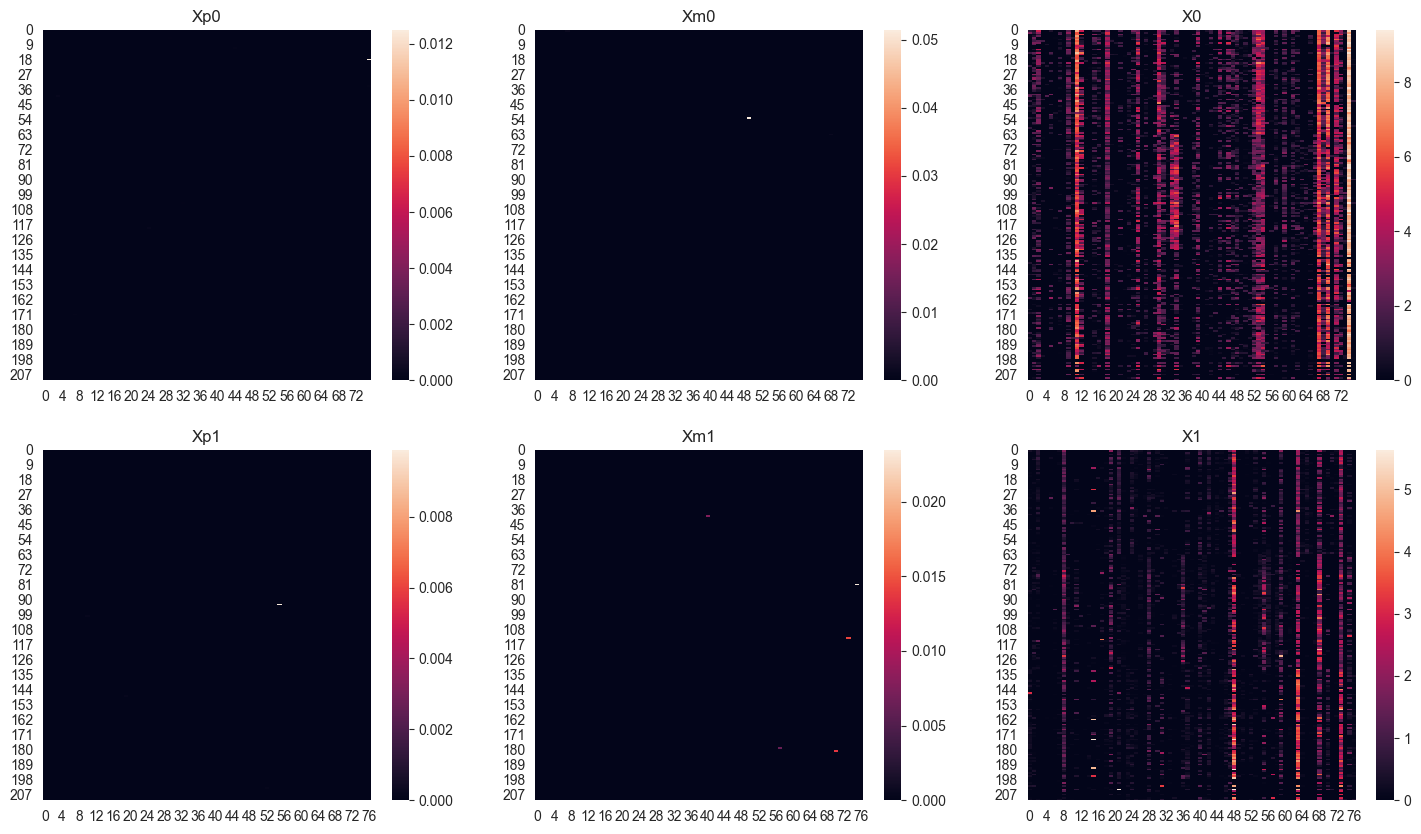

In [108]:
plt.figure(figsize=(18,10))
ax = plt.subplot(231)
sns.heatmap(Xp0,ax=ax)
plt.title('Xp0')
ax = plt.subplot(232)
sns.heatmap(Xm0,ax=ax)
plt.title('Xm0')
ax = plt.subplot(233)
sns.heatmap(expression_data_clean,ax=ax)
plt.title('X0')
ax = plt.subplot(234)
sns.heatmap(Xp1,ax=ax)
plt.title('Xp1')
ax = plt.subplot(235)
sns.heatmap(Xm1,ax=ax)
plt.title('Xm1')
ax = plt.subplot(236)
sns.heatmap(methylation_data_clean,ax=ax)
plt.title('X1')

{'NMI': 0.01930067958027491,
 'ARI': 0.0013883112934095438,
 'FMI': 0.5727570435163081}

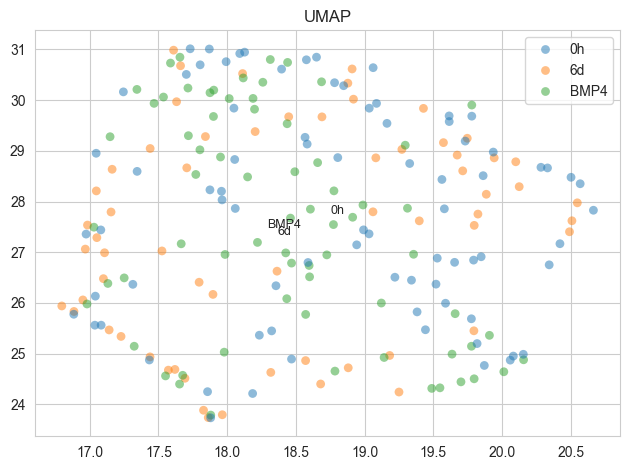

In [78]:
umap_visualize(Xp0, labels)

{'NMI': 0.02006889952378149,
 'ARI': 0.0018056390928267803,
 'FMI': 0.5620673901908491}

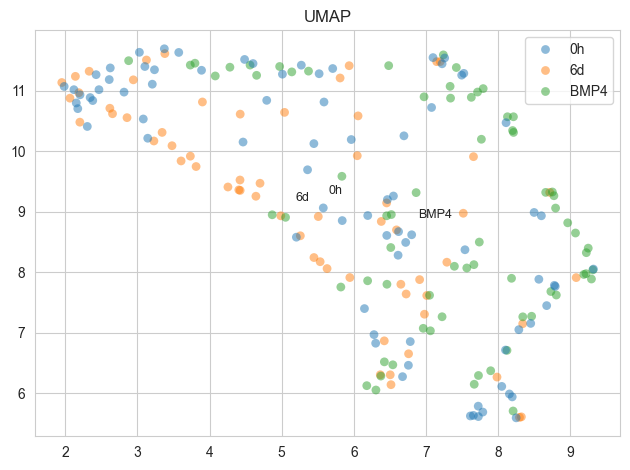

In [79]:
umap_visualize(Xp1, labels)